In [1]:
import os
import torch
import itertools
from tqdm import tqdm
import clip
import nltk
from tqdm import tqdm
import seaborn as sns
import numpy as np
import pandas as pd
import cv2 as cv
from PIL import Image
from collections import defaultdict
from itertools import combinations
import matplotlib
import matplotlib.pyplot as plt
import torch.nn.functional as F
from scipy.ndimage import label, center_of_mass
from open_clip import create_model_from_pretrained, create_model_and_transforms, get_tokenizer 
from transformers import CLIPProcessor, CLIPModel
from PIL import Image, ImageDraw, ImageFont


In [2]:
folder_dir = '/home/nsml/notebooks'
file_name = 'bush.jpeg'
file_path = os.path.join(folder_dir, file_name)

vision_model_type = 'ViT-B/16' #'ViT-B/32' #'ViT-B/16'
device = 'cuda:0'
pool_mode = 'full'
dim = 14

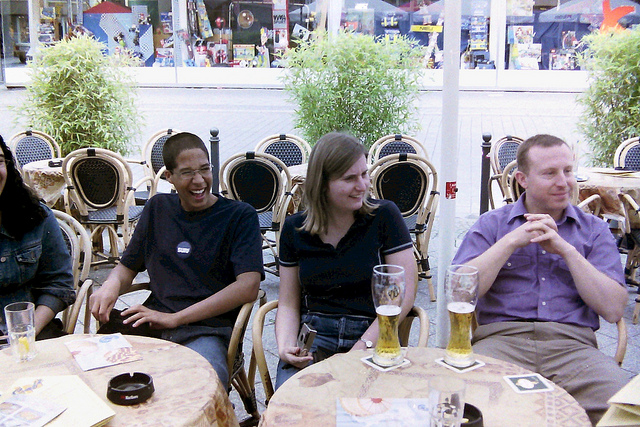

In [3]:
img = Image.open(file_path)
img.show()  

In [4]:
orig_text_lst = ['a bush of plant behind middle woman']

In [5]:
idx = 0

In [6]:
CACHE_DIR = "/mnt/tmp/"

model, preprocess = clip.load(vision_model_type, device=device)
model

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [7]:
target_layers = ['visual.transformer.resblocks[0].ln_2',
                 'visual.transformer.resblocks[1].ln_2',
                 'visual.transformer.resblocks[2].ln_2',
                 'visual.transformer.resblocks[3].ln_2',
                 'visual.transformer.resblocks[4].ln_2',
                 'visual.transformer.resblocks[5].ln_2',
                 'visual.transformer.resblocks[6].ln_2',
                 'visual.transformer.resblocks[7].ln_2',
                 'visual.transformer.resblocks[8].ln_2',
                 'visual.transformer.resblocks[9].ln_2',
                 'visual.transformer.resblocks[10].ln_2',
                 'visual.transformer.resblocks[11].ln_2']

In [8]:
def get_activation(outputs, mode):
    '''
    mode: how to pool activations: one of avg, max
    for fc or ViT neurons does no pooling
    '''
    if mode=='avg':
        def hook(model, input, output):
            # print(output.shape)
            if len(output.shape)==4: #CNN layers
                outputs.append(output.mean(dim=[2,3]).detach())
            elif len(output.shape)==3: #ViT
                if output.shape[1] == 1:
                    outputs.append(output[:, 0].clone())
                elif output.shape[1] == 0:
                    outputs.append(output[0, :].clone())
            elif len(output.shape)==2: #FC layers
                outputs.append(output.detach())
    elif mode=='max':
        def hook(model, input, output):
            if len(output.shape)==4: #CNN layers
                outputs.append(output.amax(dim=[2,3]).detach())
            elif len(output.shape)==3: #ViT
                outputs.append(output[:, 0].clone())
            elif len(output.shape)==2: #FC layers
                outputs.append(output.detach())
    elif mode=='full':
        def hook(model, input, output):
            outputs.append(output.detach())
    return hook

In [9]:
all_features = {target_layer:[] for target_layer in target_layers}
    
hooks = {}
for target_layer in tqdm(target_layers):
    command = "model.{}.register_forward_hook(get_activation(all_features[target_layer], pool_mode))".format(target_layer)
    hooks[target_layer] = eval(command)

100%|██████████| 12/12 [00:00<00:00, 7264.96it/s]


In [10]:
proj_weight = model.visual.proj
ln_post_weight = model.visual.ln_post

In [11]:
local_candidates = ['a bush']
r = 0.6

In [12]:
image = preprocess(img).unsqueeze(0).to(device)
local_text = clip.tokenize(local_candidates).to(device)
global_text = clip.tokenize(orig_text_lst).to(device)

with torch.no_grad():
    image_features = model.encode_image(image)
    local_text_features = model.encode_text(local_text)
    global_text_features = model.encode_text(global_text)
    hybrid_text_features = r * global_text_features + (1-r) * local_text_features 
    print(image_features.shape, hybrid_text_features.shape)

torch.Size([1, 512]) torch.Size([1, 512])


In [13]:
image_features /= image_features.norm(dim=-1, keepdim=True)
hybrid_text_features /= hybrid_text_features.norm(dim=-1, keepdim=True)
sim_matrix = (image_features @ hybrid_text_features.T)
sim_matrix

tensor([[0.2092]], device='cuda:0', dtype=torch.float16)

In [14]:
best_idx = sim_matrix[0].argmax(dim=-1).item()
local_candidates = [local_candidates[best_idx]]
local_candidates

['a bush']

In [15]:
for i,layer_num in enumerate(range(12)): 
    inter_features = all_features[f'visual.transformer.resblocks[{layer_num}].ln_2'][0]
    print(inter_features.shape)
    inter_features = ln_post_weight(-inter_features[:, 0, :])
    print(inter_features.shape)
    new_features_temp = inter_features @ proj_weight
    new_features_temp = new_features_temp.unsqueeze(0)
    if i == 0:
        new_features = new_features_temp
    else:
        new_features = torch.cat((new_features, new_features_temp), 0)
    print(new_features.shape)
    print()

torch.Size([197, 1, 768])
torch.Size([197, 768])
torch.Size([1, 197, 512])

torch.Size([197, 1, 768])
torch.Size([197, 768])
torch.Size([2, 197, 512])

torch.Size([197, 1, 768])
torch.Size([197, 768])
torch.Size([3, 197, 512])

torch.Size([197, 1, 768])
torch.Size([197, 768])
torch.Size([4, 197, 512])

torch.Size([197, 1, 768])
torch.Size([197, 768])
torch.Size([5, 197, 512])

torch.Size([197, 1, 768])
torch.Size([197, 768])
torch.Size([6, 197, 512])

torch.Size([197, 1, 768])
torch.Size([197, 768])
torch.Size([7, 197, 512])

torch.Size([197, 1, 768])
torch.Size([197, 768])
torch.Size([8, 197, 512])

torch.Size([197, 1, 768])
torch.Size([197, 768])
torch.Size([9, 197, 512])

torch.Size([197, 1, 768])
torch.Size([197, 768])
torch.Size([10, 197, 512])

torch.Size([197, 1, 768])
torch.Size([197, 768])
torch.Size([11, 197, 512])

torch.Size([197, 1, 768])
torch.Size([197, 768])
torch.Size([12, 197, 512])



In [16]:
new_features /= new_features.norm(dim=-1, keepdim=True)
hybrid_text_features /= hybrid_text_features.norm(dim=-1, keepdim=True)
sim_matrix = (new_features @ hybrid_text_features.T)
sim_matrix.shape

torch.Size([12, 197, 1])

In [17]:
sim_lst1 = []
sim_lst2 = []
for i in range(sim_matrix.shape[-1]):
    print('Word: ', local_candidates[i], '| Mean: ', sim_matrix[:, :, i].mean(1).mean(0).item(), '| Max: ', sim_matrix[:, :, i].max(1)[0].mean(0).item())
    print()
    sim_lst1.append(sim_matrix[:, :, i].mean(1).mean(0).item())
    sim_lst2.append(sim_matrix[:, :, i].max(1)[0].mean(0).item())

Word:  a bush | Mean:  0.2177734375 | Max:  0.279296875



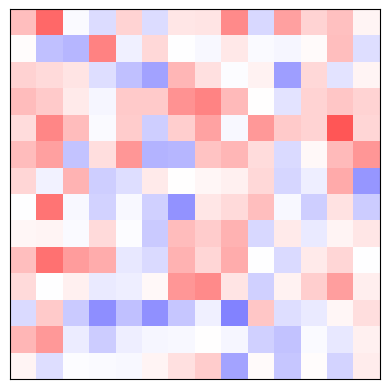

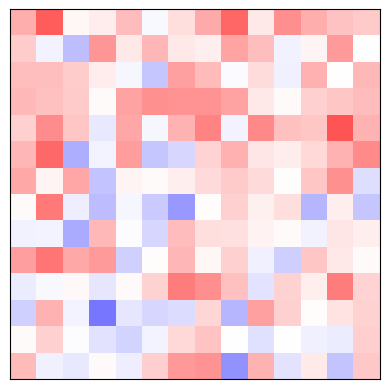

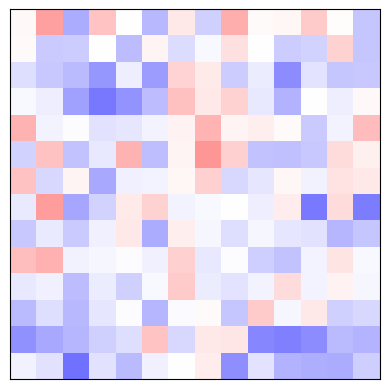

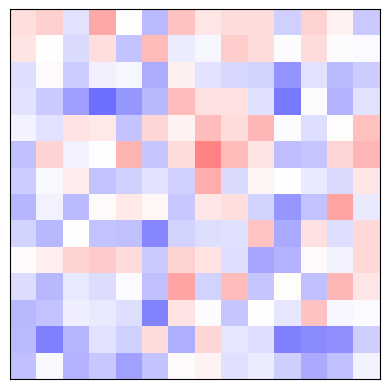

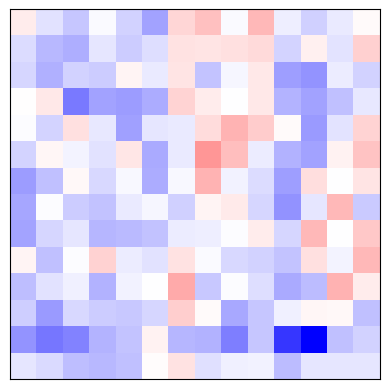

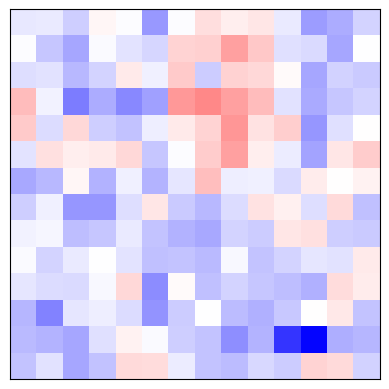

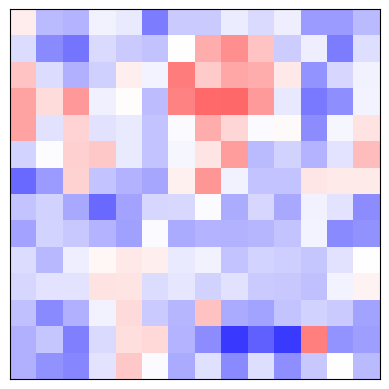

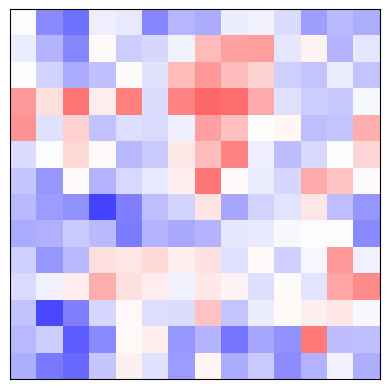

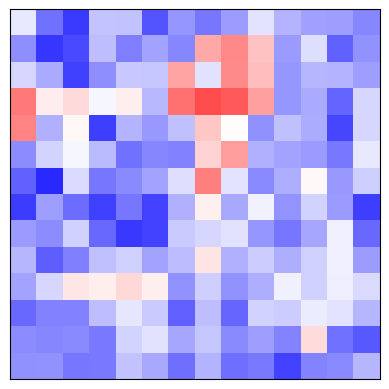

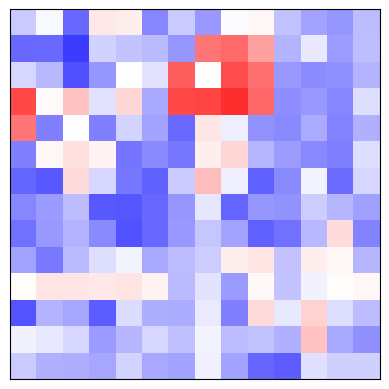

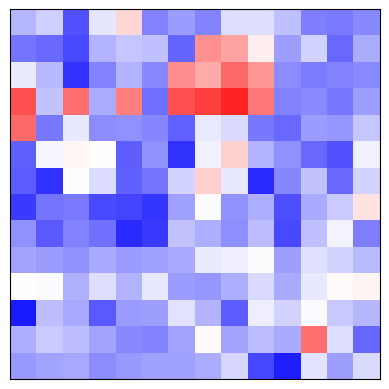

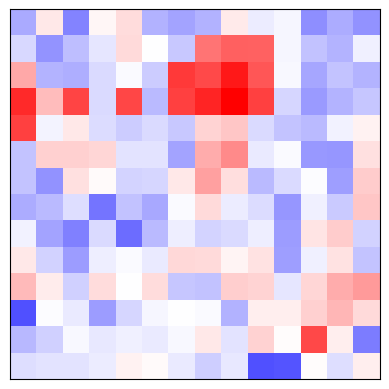

In [18]:
sns.set_style({'font.family':'serif', 'font.serif':['Times New Roman']})

cmap = plt.get_cmap('bwr')

min_v = sim_matrix[:, 1:, :].min().item()
max_v = sim_matrix[:, 1:, :].max().item()

mean_sim = sim_matrix[:, :, :].mean(0).unsqueeze(0)

clim_min = min_v
clim_max = max_v

for j in range(sim_matrix.shape[0]):
    plt.imshow(sim_matrix[j, 1:, idx].reshape(dim, dim).detach().cpu().numpy(), cmap=cmap)
    plt.xticks([])
    plt.yticks([])
    # plt.xticks(ticks=range(dim), labels=range(1, dim+1))
    # plt.yticks(ticks=range(dim), labels=range(1, dim+1))
    # plt.colorbar(shrink=0.8, aspect=20)
    plt.clim(clim_min, clim_max)
   
    # plt.title(f'Layer: {j}', fontsize=20)
    plt.show()

    low_percentile=10
    high_percentile=90

    # Flatten the array
    flattened = sim_matrix[j, :, idx].detach().cpu().numpy().flatten()
    
    # Compute percentiles
    low_threshold = np.percentile(flattened, low_percentile)
    high_threshold = np.percentile(flattened, high_percentile)
    
    # Extract low and high regions based on percentiles
    low_region = flattened[flattened <= low_threshold]
    high_region = flattened[flattened >= high_threshold]
    
    # Calculate mean values for low and high regions
    mean_low = np.mean(low_region).item()
    mean_high = np.mean(high_region).item()
    cluster_score = round(mean_high - mean_low, 2)
    
    # plt.figure(figsize=(5, 3))
    # plt.hist(sim_matrix[j, :, idx].detach().cpu().numpy(), color='#7adde3')
    # plt.axvline(mean_low, color='gray', linewidth=0.75)
    # plt.axvline(mean_high, color='gray', linewidth=0.75)
    # plt.xlim(min_v, max_v)
    # plt.tight_layout()
    # plt.title(f'{local_candidates[idx]} (Cluster score: {cluster_score})', fontsize=15) 
    # plt.show()


# plt.imshow(sim_matrix[11:, :, idx].mean(0).reshape(dim, dim).detach().cpu().numpy(), cmap=cmap)
# plt.xticks([])
# plt.yticks([])
# plt.xticks(ticks=range(dim), labels=range(1, dim+1))
# plt.yticks(ticks=range(dim), labels=range(1, dim+1))
# plt.colorbar(shrink=0.8, aspect=20)
# plt.clim(clim_min, clim_max)

# plt.title(f'{orig_text_lst[idx]} (Mean)', fontsize=15)
# plt.show()